---
# **Instructions**
Use Python code to perform the following. Be sure to comment your code explaining the actions performed
at each step.
**Note**: There are Python functions that calculate the RMSE, MAE, and accuracy automatically, but you should program these functions manually. Libraries that are allowable and will be helpful for these problems are `numpy` and `pandas`.

---

### **Assignment Setup**
Steps achieved in this section:
* Import Libraries
* Load Data
* Verify/Preview data

In [54]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [55]:
# Load the data files
house_df = pd.read_csv('https://raw.githubusercontent.com/dtavizondykstra/BU_Datasets/refs/heads/main/DSC320_MathForDataScience/housing_data.csv')
mushroom_df = pd.read_csv('https://raw.githubusercontent.com/dtavizondykstra/BU_Datasets/refs/heads/main/DSC320_MathForDataScience/mushroom_data.csv')

In [56]:
# Verify Load of house_df
house_df.head()


,sqft,sale_price,sale_price_pred
0,2416,208500,215635.4687
1,2240,181500,202432.1633
2,2272,223500,204832.7643
3,1933,140000,179401.3976
4,2853,250000,248418.6758


In [57]:
# Verify Load of mushrooms_df
mushroom_df.head()


,actual,predicted
0,p,p
1,e,e
2,e,e
3,p,p
4,e,p


---
# **Problem 1**
* **A**: Create a function that takes in two numerical arrays of the same length (think about one array
as actual values and the other as predicted values) and calculates the RMSE between them.
* **B**: Apply your RMSE function to the columns “sale price” and “sale price pred” in the file `housing data.csv`. file and report your result. The sale price has been predicted from the square footage of the house.

**Note**: The housing data.csv data set is modified version of the train.csv file from https://www.kaggle.com/c/home-data-for-ml-course/data.

In [58]:
# ---------------------------------------------------------
# Problem 1(a): RMSE function
# ---------------------------------------------------------
def rmse(actual, predicted):
    """
    Calculate the root mean square error (RMSE) between
    two numerical arrays of the same length.

    Parameters:
        actual (array-like): The true values.
        predicted (array-like): The predicted values.

    Returns:
        float: The RMSE value.
    """
    # Convert both inputs to NumPy arrays so mathematical
    # operations can be performed element by element.
    actual = np.array(actual)
    predicted = np.array(predicted)

    # Check that both arrays have the same length.
    if len(actual) != len(predicted):
        raise ValueError("Both arrays must have the same length.")

    # Calculate the squared differences between predicted and actual values.
    squared_errors = (predicted - actual) ** 2

    # Find the mean of the squared errors.
    mean_squared_error = np.mean(squared_errors)

    # Take the square root of the mean squared error.
    return np.sqrt(mean_squared_error)


In [59]:
# ---------------------------------------------------------
# Problem 1(b): Apply RMSE to housing data
# ---------------------------------------------------------
housing_rmse = rmse(house_df["sale_price"], house_df["sale_price_pred"])
print("RMSE:", housing_rmse)


RMSE: 55064.0688338987


### **Problem 1 Summary**

I created a Python function called `rmse()` that takes two numerical arrays of equal length and calculates the root mean square error. I then applied the function to the `sale_price` and `sale_price_pred` columns in `housing_data.csv`.

**RMSE result**: `55064.0688338987`

This indicates the model’s predicted home prices differ from the true prices by about $55,000 on average when squared error is considered.

---

# **Problem 2**
* **A**: Repeat problem (1a) above with MAE.

* **B**: Repeat problem (1b) above with MAE.

In [60]:
# ---------------------------------------------------------
# Problem 2(a): MAE function
# ---------------------------------------------------------
def mae(actual, predicted):
    """
    Calculate the mean absolute error (MAE) between
    two numerical arrays of the same length.

    Parameters:
        actual (array-like): The true values.
        predicted (array-like): The predicted values.

    Returns:
        float: The MAE value.
    """
    # Convert both inputs to NumPy arrays.
    actual = np.array(actual)
    predicted = np.array(predicted)

    # Check that both arrays have the same length.
    if len(actual) != len(predicted):
        raise ValueError("Both arrays must have the same length.")

    # Calculate the absolute differences between predicted and actual values.
    absolute_errors = np.abs(predicted - actual)

    # Return the average of those absolute errors.
    return np.mean(absolute_errors)


In [61]:
# ---------------------------------------------------------
# Problem 2(b): Apply MAE to housing data
# ---------------------------------------------------------
housing_mae = mae(house_df["sale_price"], house_df["sale_price_pred"])
print("MAE:", housing_mae)


MAE: 37438.68916270548


### **Problem 2 Summary**

I created a Python function called `mae()` that takes two numerical arrays of equal length and calculates the mean absolute error. I then applied the function to the `sale_price` and `sale_price_pred` columns in `housing_data.csv`.

**MAE result:** `37438.68916270548`

---

# **Problem 3**
A common metric to evaluate models with a binary target, e.g., true or false, is accuracy. The accuracy is the percentage of values the model correctly predicts.

* **A**: Build a function that takes in two binary arrays of the same length, where one is actual values and the other predicted values, that calculates the prediction accuracy.

* **B**: Apply your accuracy function to the columns “actual” and “predicted” in the mushroom data.csv file and report your result. The columns in this data set indicate the mushroom is poisonous with a “p” and if it is edible with an “e”.

**Note**: The mushroom data.csv data set is modified version of the agaricus-lepiota.data file from https://archive.ics.uci.edu/ml/datasets/mushroom.

In [62]:
# ---------------------------------------------------------
# Problem 3(a): Accuracy function
# ---------------------------------------------------------
def accuracy(actual, predicted):
    """
    Calculate prediction accuracy for two binary arrays
    of the same length.

    Parameters:
        actual (array-like): The true class labels.
        predicted (array-like): The predicted class labels.

    Returns:
        float: Accuracy as a percentage.
    """
    # Convert both inputs to NumPy arrays.
    actual = np.array(actual)
    predicted = np.array(predicted)

    # Check that both arrays have the same length.
    if len(actual) != len(predicted):
        raise ValueError("Both arrays must have the same length.")

    # Count how many predictions exactly match the actual values.
    correct_predictions = np.sum(actual == predicted)

    # Divide by the total number of values and convert to a percentage.
    return (correct_predictions / len(actual)) * 100


In [63]:
# ---------------------------------------------------------
# Problem 3(b): Apply accuracy to mushroom data
# ---------------------------------------------------------
mushroom_accuracy = accuracy(mushroom_df["actual"], mushroom_df["predicted"])
print("Accuracy:", mushroom_accuracy, "%")


Accuracy: 84.71196454948301 %


### **Problem 3 Summary**

I created a Python function called `accuracy()` that compares the actual and predicted binary class labels and calculates the percentage of correct predictions. I then applied the function to the `actual` and `predicted` columns in `mushroom_data.csv`.

**Accuracy result:** `84.71196454948301%`

---


# **Problem 4**
Assume that the error in a model is measured by the function
`f (p) = 0.005p6 − 0.27p5 + 5.998p4 − 69.919p3 + 449.17p2 − 1499.7p + 2028,`
where `p` is a parameter of the model.
* **A**: Use the Python package `matplotlib` to plot this function.

* **B**: Use your graph to estimate the value of `p` that minimizes the error. Report your result.

* **C**: Use your graph to estimate the minimum error. Report your result.


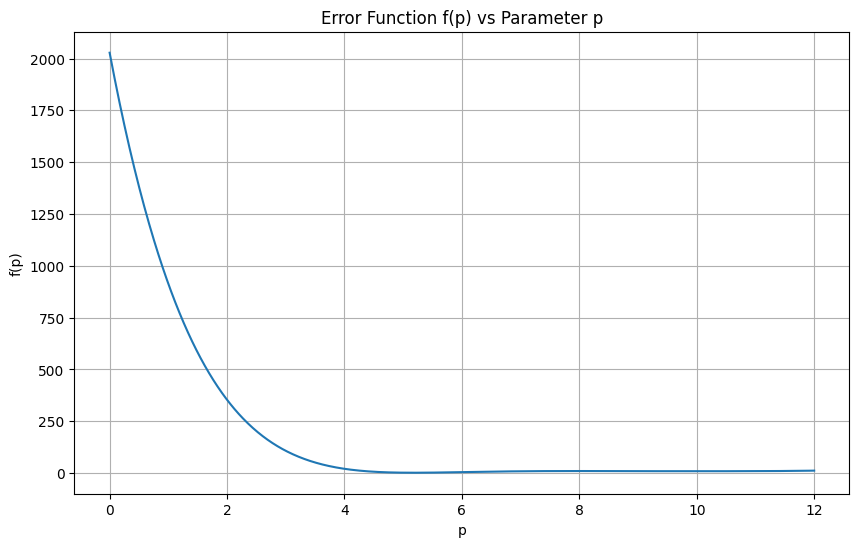

In [64]:
# ---------------------------------------------------------
# Problem 4(a): Define and plot the error function
# ---------------------------------------------------------
def error_function(p):
    """
    Compute the model error as a function of parameter p.

    f(p) = 0.005p^6 − 0.27p^5 + 5.998p^4 − 69.919p^3
           + 449.17p^2 − 1499.7p + 2028
    """
    return (
        0.005 * p**6
        - 0.27 * p**5
        + 5.998 * p**4
        - 69.919 * p**3
        + 449.17 * p**2
        - 1499.7 * p
        + 2028
    )


# Create a range of p values to plot.
# This range gives a good view of where the minimum appears.
p_values = np.linspace(0, 12, 1000)

# Compute the error for each p value.
error_values = error_function(p_values)

# Plot the function.
plt.figure(figsize=(10, 6))
plt.plot(p_values, error_values)
plt.xlabel("p")
plt.ylabel("f(p)")
plt.title("Error Function f(p) vs Parameter p")
plt.grid(True)
plt.show()


In [65]:
# ---------------------------------------------------------
# Problem 4(b) and 4(c): Estimate the minimum from the graph
# ---------------------------------------------------------
# Use a dense grid of p values to estimate where the function reaches
# its minimum value.
p_dense = np.linspace(0, 12, 100000)
error_dense = error_function(p_dense)

# Find the p value where the minimum occurs.
min_index = np.argmin(error_dense)
min_p = p_dense[min_index]
min_error = error_dense[min_index]

print("Estimated p that minimizes error:", min_p)
print("Estimated minimum error:", min_error)

Estimated p that minimizes error: 5.178291782917829
Estimated minimum error: 1.752218648060989


### **Problem 4 Summary**
I plotted the error function using Matplotlib and used the graph to estimate the parameter value that minimizes the error.

**Estimated value of p that minimizes the error**: `5.178291782917829`

**Estimated minimum error**: about `1.752218648060989`


---

# **Final Answers Summary**

* **RMSE**: 55,064.07
* **MAE**: 37,438.69
* **Accuracy**: 84.71%
* **Value of p that minimizes error**: 5.18
* **Minimum error**: 1.75

**Note**: *Values have been rounded*